In [30]:
import torch
import torch.nn as nn

torch.manual_seed(42)
np.random.seed(42)

# Pull in what preprocessing produced
from torch.utils.data import DataLoader
import joblib

import os
print(os.getcwd())
DEVICE = torch.device('cpu')

preprocessor_data = joblib.load('../data/processed/preprocessor_fdae.joblib')
scaler = preprocessor_data['scaler']
feature_columns = preprocessor_data['feature_columns']
N_FEATURES = preprocessor_data['n_features']
print(f'N_FEATURES: {N_FEATURES}')

/home/vmuser/credit-card-fraud-detection/notebooks
N_FEATURES: 44


In [31]:
stage2_data = joblib.load('../data/processed/stage2_splits.joblib')
X_s2_train_s = stage2_data['X_s2_train_s']
y_s2_train   = stage2_data['y_s2_train']
X_s2_val_s   = stage2_data['X_s2_val_s']
y_s2_val     = stage2_data['y_s2_val']
X_s2_test_s  = stage2_data['X_s2_test_s']
y_s2_test    = stage2_data['y_s2_test']
print('Stage-2 splits loaded.')

Stage-2 splits loaded.


In [32]:
from torch.utils.data import DataLoader, TensorDataset
from sklearn.preprocessing import RobustScaler
from sklearn.model_selection import train_test_split
import pandas as pd
import numpy as np
import joblib

# Load preprocessor
preprocessor_data = joblib.load('../data/processed/preprocessor_fdae.joblib')
scaler = preprocessor_data['scaler']
feature_columns = preprocessor_data['feature_columns']

# Load and process data
df = pd.read_csv('../data/raw/creditcard.csv')

# Feature engineering (must match exactly what preprocessing notebook does)
df['Hour'] = (df['Time'] % (24 * 3600)) // 3600
df['Day']  = df['Time'] // (24 * 3600)
df['Amount_log']  = np.log1p(df['Amount'])
df['Amount_sqrt'] = np.sqrt(df['Amount'])
top_features = ['V14', 'V4', 'V11', 'V12', 'V10']
for i, f1 in enumerate(top_features):
    for f2 in top_features[i + 1:]:
        df[f'{f1}_{f2}_interaction'] = df[f1] * df[f2]

# Split
X = df.drop(columns=['Class'])
y = df['Class']
X_temp, X_test, y_temp, y_test = train_test_split(X, y, test_size=0.2, random_state=42, stratify=y)
normal_mask = y_temp == 0
X_normal, y_normal = X_temp[normal_mask], y_temp[normal_mask]
X_train, X_val, y_train, y_val = train_test_split(X_normal, y_normal, test_size=0.25, random_state=42)

# Scale using the already-fitted scaler
X_train_s = pd.DataFrame(scaler.transform(X_train), columns=feature_columns)
X_val_s   = pd.DataFrame(scaler.transform(X_val),   columns=feature_columns)
X_test_s  = pd.DataFrame(scaler.transform(X_test),  columns=feature_columns)

stage2_data = joblib.load('../data/processed/stage2_splits.joblib')
X_s2_train_s = stage2_data['X_s2_train_s']
y_s2_train   = stage2_data['y_s2_train']
X_s2_val_s   = stage2_data['X_s2_val_s']
y_s2_val     = stage2_data['y_s2_val']
X_s2_test_s  = stage2_data['X_s2_test_s']
y_s2_test    = stage2_data['y_s2_test']

# Build dataloaders
def make_tensor(df): return torch.tensor(df.values, dtype=torch.float32)

train_loader = DataLoader(TensorDataset(make_tensor(X_train_s)), batch_size=256, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TensorDataset(make_tensor(X_val_s)),   batch_size=256, shuffle=False)
test_loader  = DataLoader(TensorDataset(make_tensor(X_test_s),   torch.tensor(y_test.values, dtype=torch.float32)), batch_size=256, shuffle=False)


# Stage-2 supervised dataloaders

stage2_train_loader = DataLoader(
    TensorDataset(
        make_tensor(X_s2_train_s),
        torch.tensor(y_s2_train.values, dtype=torch.float32)
    ),
    batch_size=256,
    shuffle=False
)

stage2_val_loader = DataLoader(
    TensorDataset(
        make_tensor(X_s2_val_s),
        torch.tensor(y_s2_val.values, dtype=torch.float32)
    ),
    batch_size=256,
    shuffle=False
)

stage2_test_loader = DataLoader(
    TensorDataset(
        make_tensor(X_s2_test_s),
        torch.tensor(y_s2_test.values, dtype=torch.float32)
    ),
    batch_size=256,
    shuffle=False
)

print(f'train: {len(train_loader)} batches | val: {len(val_loader)} batches | test: {len(test_loader)} batches')
print('Stage-2 dataloaders ready.')

train: 666 batches | val: 223 batches | test: 223 batches
Stage-2 dataloaders ready.


In [33]:
def add_gaussian_noise(x: torch.Tensor, noise_factor: float = 0.1) -> torch.Tensor:
    noise = torch.randn_like(x) * noise_factor
    return x + noise

In [34]:
class FDAE(nn.Module):
    
    def __init__(self, n_features: int):
        super().__init__()
        
        self.encoder = nn.Sequential(
            nn.Linear(n_features, 64),
            nn.ELU(),                    # ← ELU instead of ReLU
            nn.Linear(64, 32),
            nn.ELU(),
            nn.Linear(32, 16),
            nn.ELU(),
            nn.Linear(16, 8)             # ← no activation on latent
        )
        
        self.decoder = nn.Sequential(
            nn.Linear(8, 16),
            nn.ELU(),
            nn.Linear(16, 32),
            nn.ELU(),
            nn.Linear(32, 64),
            nn.ELU(),
            nn.Linear(64, n_features)    # ← no activation on output
        )
    
    def forward(self, x):
        z = self.encoder(x)
        x_hat = self.decoder(z)
        return x_hat, z


# Initialise and sanity check
model = FDAE(n_features=N_FEATURES)
print(model)

dummy = torch.randn(8, N_FEATURES)
x_hat, z = model(dummy)
print(f'Input  : {dummy.shape}')
print(f'Output : {x_hat.shape}')
print(f'Latent : {z.shape}')

FDAE(
  (encoder): Sequential(
    (0): Linear(in_features=44, out_features=64, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=64, out_features=32, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=32, out_features=16, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=16, out_features=8, bias=True)
  )
  (decoder): Sequential(
    (0): Linear(in_features=8, out_features=16, bias=True)
    (1): ELU(alpha=1.0)
    (2): Linear(in_features=16, out_features=32, bias=True)
    (3): ELU(alpha=1.0)
    (4): Linear(in_features=32, out_features=64, bias=True)
    (5): ELU(alpha=1.0)
    (6): Linear(in_features=64, out_features=44, bias=True)
  )
)
Input  : torch.Size([8, 44])
Output : torch.Size([8, 44])
Latent : torch.Size([8, 8])


In [35]:
def fdae_loss(x_hat, x_clean, z, lambda1=0.5):
    """
    Combined loss for the FDAE.
    
    Args:
        x_hat   : reconstructed output from the model
        x_clean : original clean input (before noise was added)
        z       : latent vector from the encoder
        lambda1 : weight for the latent regularisation term
    
    Returns:
        total loss, reconstruction loss, latent loss  (all three for logging)
    """
    # Reconstruction + denoising (one term, two jobs)
    l_recon = nn.functional.mse_loss(x_hat, x_clean)
    
    # Latent regularisation — push z toward origin
    zeros = torch.zeros_like(z)
    l_latent = nn.functional.mse_loss(z, zeros)
    
    # Combined
    total = l_recon + lambda1 * l_latent
    
    return total, l_recon, l_latent

In [36]:
# Sanity check
dummy_x = torch.randn(8, N_FEATURES)
dummy_x_noisy = add_gaussian_noise(dummy_x, noise_factor=0.1)

x_hat, z = model(dummy_x_noisy)
total, l_recon, l_latent = fdae_loss(x_hat, dummy_x, z)

print(f'Total loss  : {total.item():.4f}')
print(f'Recon loss  : {l_recon.item():.4f}')
print(f'Latent loss : {l_latent.item():.4f}')

Total loss  : 0.9486
Recon loss  : 0.9325
Latent loss : 0.0321


In [37]:
optimizer = torch.optim.Adam(model.parameters(), lr=1e-3)

In [38]:
def train_fdae(model, train_loader, val_loader, optimizer, 
               epochs=50, noise_factor=0.1, lambda1=0.5):
    """
    Training loop for the FDAE.
    
    Each epoch:
      - trains on normal-only batches with noisy input
      - validates on normal-only val set
      - logs all three loss components
    """
    history = {
        'train_total': [], 'train_recon': [], 'train_latent': [],
        'val_total':   [], 'val_recon':   [], 'val_latent':   []
    }

    for epoch in range(epochs):

        # ── Training phase ──────────────────────────────────────
        model.train()
        train_total, train_recon, train_latent = 0, 0, 0

        for batch in train_loader:
            x_clean = batch[0]

            # Add noise for denoising objective
            x_noisy = add_gaussian_noise(x_clean, noise_factor)

            # Forward pass
            x_hat, z = model(x_noisy)

            # Loss
            loss, l_recon, l_latent = fdae_loss(x_hat, x_clean, z, lambda1)

            # Backward pass
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()

            train_total  += loss.item()
            train_recon  += l_recon.item()
            train_latent += l_latent.item()

        # Average over batches
        n = len(train_loader)
        train_total  /= n
        train_recon  /= n
        train_latent /= n

        # ── Validation phase ─────────────────────────────────────
        model.eval()
        val_total, val_recon, val_latent = 0, 0, 0

        with torch.no_grad():
            for batch in val_loader:
                x_clean = batch[0]
                x_noisy = add_gaussian_noise(x_clean, noise_factor)
                x_hat, z = model(x_noisy)
                loss, l_recon, l_latent = fdae_loss(x_hat, x_clean, z, lambda1)
                val_total  += loss.item()
                val_recon  += l_recon.item()
                val_latent += l_latent.item()

        n = len(val_loader)
        val_total  /= n
        val_recon  /= n
        val_latent /= n

        # ── Logging ──────────────────────────────────────────────
        history['train_total'].append(train_total)
        history['train_recon'].append(train_recon)
        history['train_latent'].append(train_latent)
        history['val_total'].append(val_total)
        history['val_recon'].append(val_recon)
        history['val_latent'].append(val_latent)

        if (epoch + 1) % 5 == 0:
            print(f'Epoch {epoch+1:3d}/{epochs} | '
                  f'Train: {train_total:.4f} (recon {train_recon:.4f}, latent {train_latent:.4f}) | '
                  f'Val: {val_total:.4f} (recon {val_recon:.4f}, latent {val_latent:.4f})')

    return history

In [39]:
history = train_fdae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=50,
    noise_factor=0.1,
    lambda1=0.5
)

Epoch   5/50 | Train: 1.4295 (recon 1.3718, latent 0.1155) | Val: 1.5611 (recon 1.5129, latent 0.0964)
Epoch  10/50 | Train: 1.1877 (recon 1.1506, latent 0.0740) | Val: 1.0561 (recon 1.0307, latent 0.0509)
Epoch  15/50 | Train: 1.0312 (recon 0.9979, latent 0.0666) | Val: 0.8900 (recon 0.8675, latent 0.0451)
Epoch  20/50 | Train: 0.8552 (recon 0.8283, latent 0.0539) | Val: 0.7967 (recon 0.7771, latent 0.0393)
Epoch  25/50 | Train: 0.8495 (recon 0.8248, latent 0.0495) | Val: 0.7025 (recon 0.6826, latent 0.0397)
Epoch  30/50 | Train: 0.7066 (recon 0.6840, latent 0.0451) | Val: 0.7525 (recon 0.7366, latent 0.0319)
Epoch  35/50 | Train: 0.6705 (recon 0.6503, latent 0.0403) | Val: 0.6264 (recon 0.6104, latent 0.0319)
Epoch  40/50 | Train: 0.6441 (recon 0.6249, latent 0.0384) | Val: 0.6319 (recon 0.6157, latent 0.0325)
Epoch  45/50 | Train: 0.6023 (recon 0.5847, latent 0.0351) | Val: 0.9929 (recon 0.9773, latent 0.0313)
Epoch  50/50 | Train: 0.6487 (recon 0.6312, latent 0.0349) | Val: 0.6401 

In [40]:
torch.save(model.state_dict(), '../data/processed/fdae_model.pt')
print('Model saved.')

Model saved.


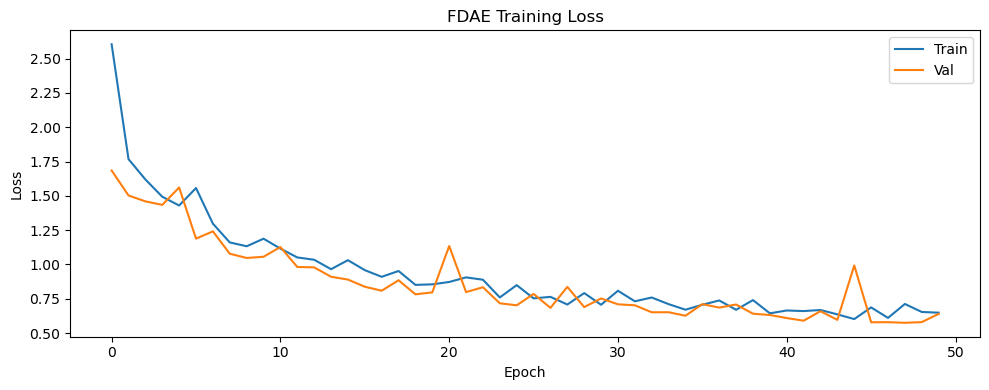

In [41]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 4))
plt.plot(history['train_total'], label='Train')
plt.plot(history['val_total'], label='Val')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.title('FDAE Training Loss')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/loss_curve.png')
plt.show()

In [42]:
def compute_anomaly_scores(model, test_loader):
    """
    Compute per-transaction anomaly scores on the test set.
    
    Score = reconstruction error + latent distance
    No noise added — we want true reconstruction ability.
    
    Returns:
        scores : numpy array of anomaly scores, one per transaction
        labels : numpy array of true labels (0=normal, 1=fraud)
    """
    model.eval()
    all_scores = []
    all_labels = []

    with torch.no_grad():
        for batch in test_loader:
            x_clean, y_true = batch

            # Forward pass — clean input, no noise
            x_hat, z = model(x_clean)

            # Reconstruction error per transaction
            recon_error = ((x_hat - x_clean) ** 2).mean(dim=1)

            # Latent distance per transaction
            latent_dist = (z ** 2).mean(dim=1)

            # Combined anomaly score
            score = recon_error + 0.5 * latent_dist

            all_scores.append(score.numpy())
            all_labels.append(y_true.numpy())

    scores = np.concatenate(all_scores)
    labels = np.concatenate(all_labels)

    return scores, labels

def extract_fdae_features(model, dataloader):
    """
    Extract rich FDAE representations for stage-2 classification.

    Returns:
        X_features
        y_labels
    """

    model.eval()

    all_features = []
    all_labels = []

    with torch.no_grad():

        for batch in dataloader:

            x, y = batch

            x_hat, z = model(x)

            recon_error = ((x_hat - x) ** 2).mean(dim=1)
            latent_dist = (z ** 2).mean(dim=1)

            combined = torch.cat([
                recon_error.unsqueeze(1),
                latent_dist.unsqueeze(1),
                z
            ], dim=1)

            all_features.append(combined.numpy())
            all_labels.append(y.numpy())

    X = np.concatenate(all_features)
    y = np.concatenate(all_labels)

    return X, y


# Run it
scores, labels = compute_anomaly_scores(model, test_loader)

print(f'Test transactions : {len(scores):,}')
print(f'Fraud transactions: {int(labels.sum())}')
print(f'\nScore stats:')
print(f'  Normal — mean: {scores[labels==0].mean():.4f}, '
      f'max: {scores[labels==0].max():.4f}')
print(f'  Fraud  — mean: {scores[labels==1].mean():.4f}, '
      f'max: {scores[labels==1].max():.4f}')

Test transactions : 56,962
Fraud transactions: 98

Score stats:
  Normal — mean: 0.6611, max: 164.2033
  Fraud  — mean: 269.0653, max: 3855.8513


ROC-AUC Score        : 0.9627
Average Precision    : 0.6384


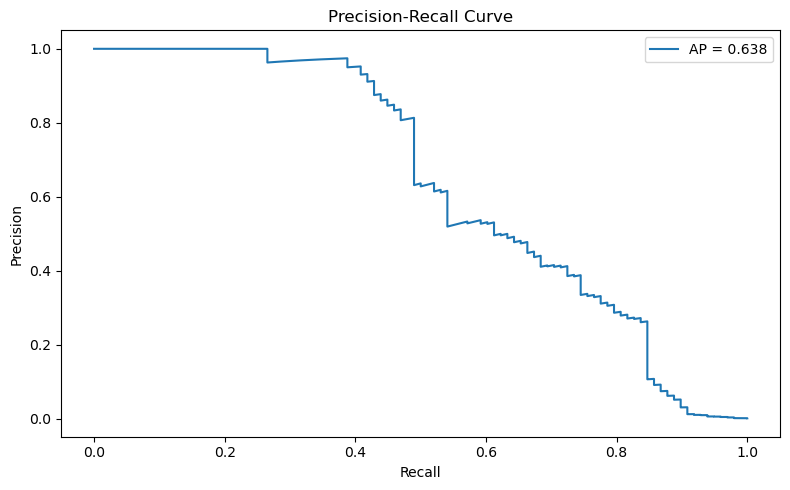


Best threshold : 94.2772
Best F1 score  : 0.6115

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.81      0.49      0.61        98

    accuracy                           1.00     56962
   macro avg       0.91      0.74      0.81     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56853    11]
 [   50    48]]
Stage-2 feature shapes:
Train: (170883, 10)
Val  : (56962, 10)
Test : (56962, 10)


In [43]:
from sklearn.metrics import (precision_recall_curve, roc_auc_score,
                             classification_report, confusion_matrix,
                             average_precision_score)
import matplotlib.pyplot as plt

# Precision-Recall curve
precision, recall, thresholds = precision_recall_curve(labels, scores)
avg_precision = average_precision_score(labels, scores)
roc_auc = roc_auc_score(labels, scores)

print(f'ROC-AUC Score        : {roc_auc:.4f}')
print(f'Average Precision    : {avg_precision:.4f}')

plt.figure(figsize=(8, 5))
plt.plot(recall, precision, label=f'AP = {avg_precision:.3f}')
plt.xlabel('Recall')
plt.ylabel('Precision')
plt.title('Precision-Recall Curve')
plt.legend()
plt.tight_layout()
plt.savefig('../data/processed/pr_curve.png')
plt.show()

# Pick threshold that maximises F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]
best_f1 = f1_scores[best_idx]

print(f'\nBest threshold : {best_threshold:.4f}')
print(f'Best F1 score  : {best_f1:.4f}')

# Final classification report
predictions = (scores >= best_threshold).astype(int)
print('\nClassification Report:')
print(classification_report(labels, predictions, 
                            target_names=['Normal', 'Fraud']))

print('Confusion Matrix:')
print(confusion_matrix(labels, predictions))

X_stage2_train, y_stage2_train = extract_fdae_features(
    model,
    stage2_train_loader
)

X_stage2_val, y_stage2_val = extract_fdae_features(
    model,
    stage2_val_loader
)

X_stage2_test, y_stage2_test = extract_fdae_features(
    model,
    stage2_test_loader
)

print('Stage-2 feature shapes:')
print(f'Train: {X_stage2_train.shape}')
print(f'Val  : {X_stage2_val.shape}')
print(f'Test : {X_stage2_test.shape}')

In [44]:
custom_threshold = 50.0
predictions = (scores >= custom_threshold).astype(int)
print(classification_report(labels, predictions, target_names=['Normal', 'Fraud']))

              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.61      0.53      0.57        98

    accuracy                           1.00     56962
   macro avg       0.81      0.77      0.78     56962
weighted avg       1.00      1.00      1.00     56962



In [45]:
# Fresh model — reset weights
model = FDAE(n_features=N_FEATURES)

# Lower learning rate — fixes the instability we saw in the loss curve
optimizer = torch.optim.Adam(model.parameters(), lr=5e-4)

# Retrain with adjustments
history = train_fdae(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    optimizer=optimizer,
    epochs=100,          # longer training
    noise_factor=0.15,   # slightly more noise — harder denoising task
    lambda1=0.8          # tighter latent space — pushes fraud further out
)

torch.save(model.state_dict(), '../data/processed/fdae_model_v2.pt')

Epoch   5/100 | Train: 1.6844 (recon 1.6252, latent 0.0741) | Val: 1.6032 (recon 1.5659, latent 0.0466)
Epoch  10/100 | Train: 1.4257 (recon 1.3811, latent 0.0558) | Val: 1.3107 (recon 1.2779, latent 0.0411)
Epoch  15/100 | Train: 1.1900 (recon 1.1540, latent 0.0450) | Val: 1.1200 (recon 1.0926, latent 0.0343)
Epoch  20/100 | Train: 1.0660 (recon 1.0323, latent 0.0421) | Val: 1.0053 (recon 0.9792, latent 0.0326)
Epoch  25/100 | Train: 0.9249 (recon 0.8926, latent 0.0404) | Val: 0.9017 (recon 0.8769, latent 0.0309)
Epoch  30/100 | Train: 0.8746 (recon 0.8460, latent 0.0356) | Val: 0.8093 (recon 0.7866, latent 0.0284)
Epoch  35/100 | Train: 0.8693 (recon 0.8444, latent 0.0311) | Val: 0.7619 (recon 0.7419, latent 0.0250)
Epoch  40/100 | Train: 0.7342 (recon 0.7114, latent 0.0285) | Val: 0.7255 (recon 0.7073, latent 0.0228)
Epoch  45/100 | Train: 0.7233 (recon 0.7025, latent 0.0260) | Val: 0.7173 (recon 0.7002, latent 0.0214)
Epoch  50/100 | Train: 0.6952 (recon 0.6756, latent 0.0244) | Va

In [46]:
# Evaluate v2
scores_v2, labels_v2 = compute_anomaly_scores(model, test_loader)

print(f'Score stats (v2):')
print(f'  Normal — mean: {scores_v2[labels_v2==0].mean():.4f}')
print(f'  Fraud  — mean: {scores_v2[labels_v2==1].mean():.4f}')

# Metrics
precision, recall, thresholds = precision_recall_curve(labels_v2, scores_v2)
avg_precision = average_precision_score(labels_v2, scores_v2)
roc_auc = roc_auc_score(labels_v2, scores_v2)

print(f'\nROC-AUC          : {roc_auc:.4f}')
print(f'Average Precision: {avg_precision:.4f}')

# Best threshold by F1
f1_scores = 2 * (precision * recall) / (precision + recall + 1e-8)
best_idx = f1_scores.argmax()
best_threshold = thresholds[best_idx]

predictions = (scores_v2 >= best_threshold).astype(int)
print(f'\nBest threshold: {best_threshold:.4f}')
print('\nClassification Report:')
print(classification_report(labels_v2, predictions, target_names=['Normal', 'Fraud']))
print('Confusion Matrix:')
print(confusion_matrix(labels_v2, predictions))

Score stats (v2):
  Normal — mean: 0.5523
  Fraud  — mean: 280.8613

ROC-AUC          : 0.9618
Average Precision: 0.5928

Best threshold: 56.1296

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.79      0.50      0.61        98

    accuracy                           1.00     56962
   macro avg       0.89      0.75      0.81     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56851    13]
 [   49    49]]


In [47]:
from xgboost import XGBClassifier

# Train XGBoost stage-2 classifier

fraud_weight = (
    (y_stage2_train == 0).sum()
    /
    (y_stage2_train == 1).sum()
)

print(f'Fraud weight: {fraud_weight:.2f}')

xgb_model = XGBClassifier(
    n_estimators=300,
    max_depth=5,
    learning_rate=0.05,
    subsample=0.8,
    colsample_bytree=0.8,
    scale_pos_weight=fraud_weight,
    eval_metric='logloss',
    random_state=42
)

xgb_model.fit(
    X_stage2_train,
    y_stage2_train
)

print('XGBoost training complete.')

# Validation threshold tuning


val_probs = xgb_model.predict_proba(X_stage2_val)[:, 1]

precision, recall, thresholds = precision_recall_curve(
    y_stage2_val,
    val_probs
)

f1_scores = (
    2 * precision * recall
    /
    (precision + recall + 1e-8)
)

best_idx = f1_scores.argmax()

best_threshold = thresholds[best_idx]

print(f'Best threshold: {best_threshold:.4f}')
print(f'Best validation F1: {f1_scores[best_idx]:.4f}')

Fraud weight: 578.26
XGBoost training complete.
Best threshold: 0.9905
Best validation F1: 0.8152


In [48]:
# Final stage-2 evaluation


test_probs = xgb_model.predict_proba(X_stage2_test)[:, 1]

test_preds = (
    test_probs >= best_threshold
).astype(int)

print('\nClassification Report:')
print(classification_report(
    y_stage2_test,
    test_preds,
    target_names=['Normal', 'Fraud']
))

print('Confusion Matrix:')
print(confusion_matrix(
    y_stage2_test,
    test_preds
))

print(f'\nROC-AUC: {roc_auc_score(y_stage2_test, test_probs):.4f}')

print(f'Average Precision: '
      f'{average_precision_score(y_stage2_test, test_probs):.4f}')


Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      1.00      1.00     56864
       Fraud       0.80      0.80      0.80        98

    accuracy                           1.00     56962
   macro avg       0.90      0.90      0.90     56962
weighted avg       1.00      1.00      1.00     56962

Confusion Matrix:
[[56845    19]
 [   20    78]]

ROC-AUC: 0.9577
Average Precision: 0.7839
